Here, we will build the actual pairs-trading signal engine \\ turn the statistics into the strategy 

1. Set-up

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)

prices = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "clean_prices.csv",
    index_col=0,
    parse_dates=True
).dropna()

prices.head()

Project root: /workspaces/quant-pairs-trading


,KO,PEP
Date,,
2018-01-02,34.816475,89.690910
2018-01-03,34.740017,89.455414
2018-01-04,35.229328,89.896042
2018-01-05,35.221661,90.154335
2018-01-08,35.168156,89.637733


2. Reconstruct the spread 

In [5]:
log_prices = np.log(prices)

log_ko = log_prices["KO"]
log_pep = log_prices["PEP"]

In [6]:
#Use the hedge ratio we estimated previously

import statsmodels.api as sm

X = sm.add_constant(log_pep)
model = sm.OLS(log_ko, X).fit()

alpha = model.params["const"]
beta = model.params["PEP"]

spread = log_ko - beta * log_pep

print(f"Alpha: {alpha:.6f}")
print(f"Beta: {beta:.6f}")

Alpha: -0.604734
Beta: 0.936565


3. Calculate the (60days) rolling z-score \\ don't use the full dataset's mean and standard deviation, because that would introduce look-ahead bias. 

In [7]:
window = 60

rolling_mean = spread.rolling(window).mean()
rolling_std = spread.rolling(window).std()

z_score = (spread - rolling_mean) / rolling_std

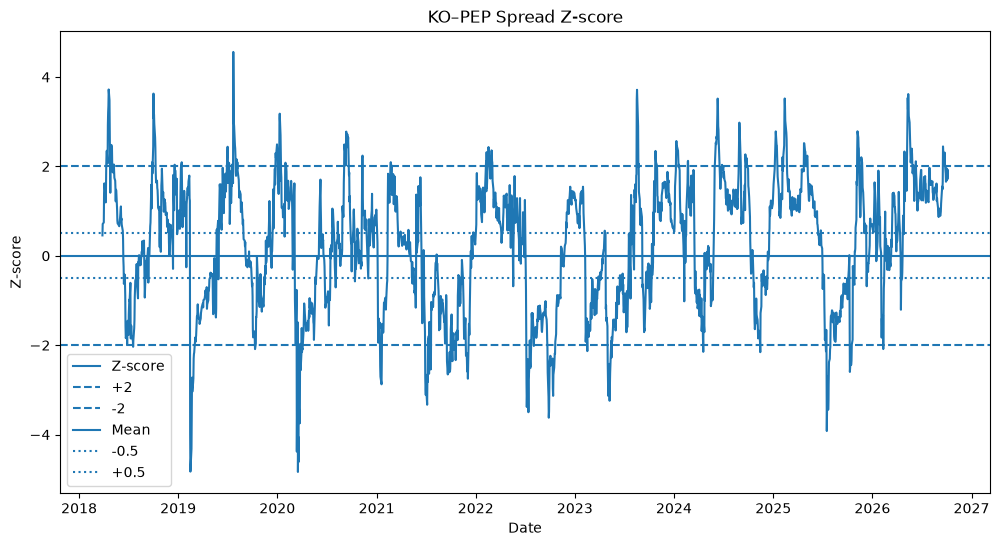

In [8]:
#plot it 

plt.figure(figsize=(12, 6))

plt.plot(z_score, label="Z-score")
plt.axhline(2, linestyle="--", label="+2")
plt.axhline(-2, linestyle="--", label="-2")
plt.axhline(0, linestyle="-", label="Mean")
plt.axhline(-0.5, linestyle=":", label="-0.5")
plt.axhline(0.5, linestyle=":", label="+0.5")

plt.title("KO–PEP Spread Z-score")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.show()

4. Define the trading rules 
Here, we will use... 
| Z-score           | Position     |
| ----------------- | ------------ |
| `Z > +2`          | Short spread |
| `Z < -2`          | Long spread  |
| `-0.5 ≤ Z ≤ +0.5` | Exit         |
| Otherwise         | Hold         |

But there's an important problem.

This code would re-enter repeatedly while Z remains above 2. We want a proper position that stays open until the exit condition.


In [9]:
#build a stateful condition 

position = pd.Series(0, index=z_score.index)

current_position = 0

for date in z_score.index:
    z = z_score.loc[date]

    if current_position == 0:
        if z < -2:
            current_position = 1
        elif z > 2:
            current_position = -1

    elif current_position == 1:
        if z > -0.5:
            current_position = 0

    elif current_position == -1:
        if z < 0.5:
            current_position = 0

    position.loc[date] = current_position

In [10]:
# check the result 

position.value_counts()

 0    1101
-1     682
 1     419
Name: count, dtype: int64

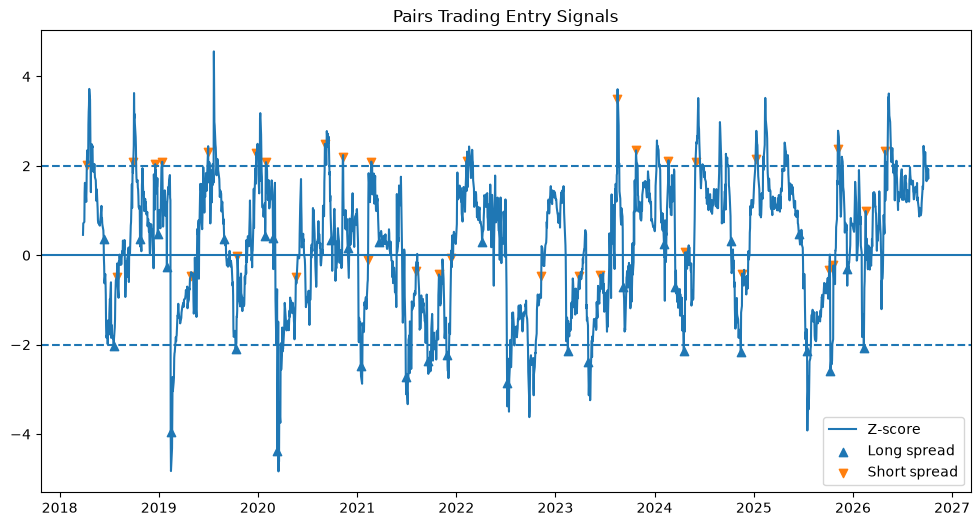

In [11]:
# visualize entries 

plt.figure(figsize=(12, 6))

plt.plot(z_score, label="Z-score")

plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.axhline(0, linestyle="-")

long_entries = position.diff() == 1
short_entries = position.diff() == -1

plt.scatter(
    z_score.index[long_entries],
    z_score[long_entries],
    marker="^",
    label="Long spread"
)

plt.scatter(
    z_score.index[short_entries],
    z_score[short_entries],
    marker="v",
    label="Short spread"
)

plt.title("Pairs Trading Entry Signals")
plt.legend()
plt.show()

Overall, the short/long positions are well allocated. 

5. Save the signals 

In [12]:
strategy_data = pd.DataFrame({
    "KO": prices["KO"],
    "PEP": prices["PEP"],
    "spread": spread,
    "z_score": z_score,
    "position": position
})

# error shooting : path needed to be specified to the local file instead of '../data/processed'
from pathlib import Path

output_path = Path("data/processed/strategy_signals.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

strategy_data.to_csv(output_path)

print(f"Strategy signals saved to: {output_path}")

print("Strategy signals saved.")

Strategy signals saved to: data/processed/strategy_signals.csv
Strategy signals saved.


Next, we will calculate actual strategy returns, equity curve, Sharpe ratio, maximum drawdown, and win rate. 